# GPU execution of the heavy kernels
Three of the heaviest kernels of the library have a second implementation written in jax, which
runs on a GPU: the Lindhard sum behind the RPA response functions (spin and charge
susceptibilities, IETS maps, RPA magnon bands, the static polarizability behind the screened
interaction), the Chebyshev moments behind the KPM, and the batched diagonalization of the
Bloch Hamiltonian over a k-mesh. Which implementation runs is decided by one package-wide switch,
`gpu.set_gpu(True)`, and the package stays on the CPU until that switch is set, so a script
that never calls it computes the same thing on whichever machine it lands on.

Precision is chosen per call, since it changes the numbers and not only where they are computed:
`chi_prec` for the Lindhard sum, `kpm_prec` for the Chebyshev moments and `eigh_prec` for the
batched diagonalization, each `"single"` or `"double"`. Double precision is the default
everywhere except the Lindhard sum on the GPU, where single precision is the default because a
consumer card can be an order of magnitude slower in double precision.

Asking for a GPU where there is none is not an error: the same jax kernels then run on jax's own
CPU backend, with a warning, and give the same numbers. This notebook was executed on a machine
without a GPU, so what it shows is that the two code paths agree, not how much faster the device
is.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import gpu

print("GPU visible to jax:",gpu.is_gpu_available())
print("GPU switch on by default:",gpu.get_gpu())

GPU visible to jax: False
GPU switch on by default: False


### The RPA spin response on both code paths
We take the Neel antiferromagnet of the honeycomb Hubbard model at the mean-field level and
compute the momentum-resolved RPA spin spectral function, whose low-energy branch is the magnon
dispersion, first on the CPU and then with the switch set. On the GPU the Lindhard sum defaults
to single precision; the RPA dressing amplifies that rounding close to the Goldstone mode at
$q=0$, which is where the two maps differ most, and `chi_prec="double"` brings the difference
down to rounding error.

../../../src/pyqula/gpu.py:74: UserWarning: pyqula.gpu.set_gpu(True): jax sees no GPU on this machine, so the GPU code paths will run on jax's CPU backend instead
  warnings.warn("pyqula.gpu.set_gpu(True): jax sees no GPU on this "


largest relative difference, single precision = 7.140214839442634e-05
largest relative difference, double precision = 1.9828081160195976e-13


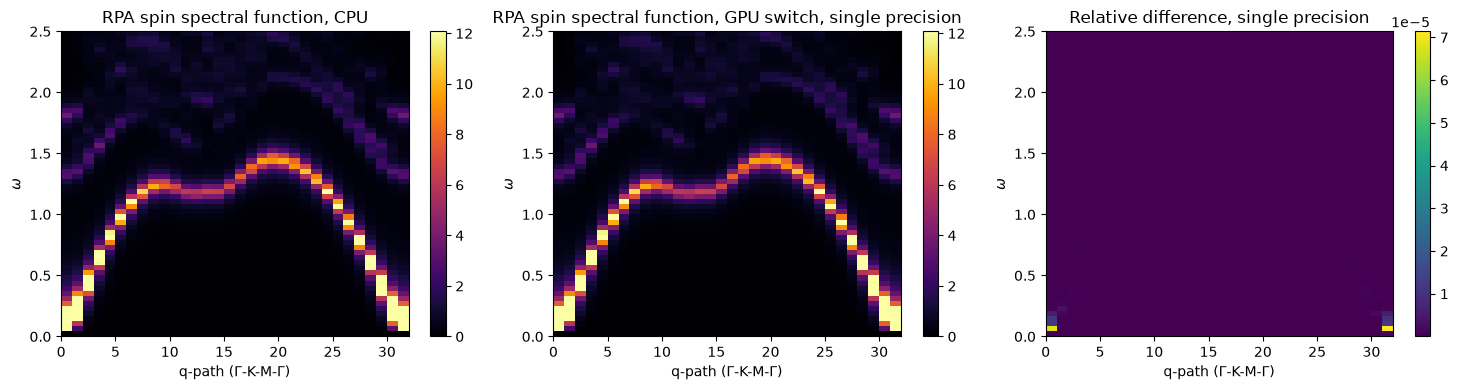

In [2]:
g = geometry.honeycomb_lattice() # two sites per cell
h = g.get_hamiltonian() # first-neighbor hopping
hmf = h.get_mean_field_hamiltonian(U=3.0,filling=0.5,mf="antiferro",nk=8,verbose=0) # Neel state
es = np.linspace(0.,2.5,60) # frequencies
qpath = ["G","K","M","G"] # path in reciprocal space

gpu.set_gpu(False) # the CPU kernel
(qs,es,chi_cpu) = hmf.get_qdos_iets(energies=es,qpath=qpath,nq=24,nk=8,delta=0.05)
gpu.set_gpu(True) # the jax kernel, on the device if there is one
(qs,es,chi_gpu) = hmf.get_qdos_iets(energies=es,qpath=qpath,nq=24,nk=8,delta=0.05)
(qs,es,chi_gpu_double) = hmf.get_qdos_iets(energies=es,qpath=qpath,nq=24,nk=8,delta=0.05,
                                           chi_prec="double")
gpu.set_gpu(False) # back to the CPU
scale = np.max(np.abs(chi_cpu))
print("largest relative difference, single precision =",np.max(np.abs(chi_gpu-chi_cpu))/scale)
print("largest relative difference, double precision =",np.max(np.abs(chi_gpu_double-chi_cpu))/scale)

fig,axs = plt.subplots(1,3,figsize=(15,4))
vmax = np.percentile(np.abs(chi_cpu),98)
for ax,chi,title in [(axs[0],chi_cpu,"CPU"),(axs[1],chi_gpu,"GPU switch, single precision")]:
    im = ax.imshow(np.abs(chi).T,origin="lower",aspect="auto",cmap="inferno",vmax=vmax,
                   extent=[0,len(qs),es[0],es[-1]])
    ax.set_title("RPA spin spectral function, "+title)
    plt.colorbar(im,ax=ax)
im = axs[2].imshow(np.abs(chi_gpu-chi_cpu).T/scale,origin="lower",aspect="auto",cmap="viridis",
                   extent=[0,len(qs),es[0],es[-1]])
axs[2].set_title("Relative difference, single precision")
plt.colorbar(im,ax=axs[2])
for ax in axs:
    ax.set_xlabel("q-path ($\\Gamma$-K-M-$\\Gamma$)") ; ax.set_ylabel("$\\omega$")
plt.tight_layout()
plt.show()

### Batched diagonalization over a k-mesh
The batched diagonalization only goes to the device for matrices of 32 orbitals or more, since
below that size the GPU does not pay, so we take a $4\times4$ supercell of the honeycomb lattice,
64 orbitals counting the spin, with a strong onsite defect and a Haldane term, and map the
lowest positive energy over the Brillouin zone of the supercell on both paths. Without a GPU
both paths end up calling the same LAPACK routine, so here the two agree to the last digit.

../../../src/pyqula/gpu.py:74: UserWarning: pyqula.gpu.set_gpu(True): jax sees no GPU on this machine, so the GPU code paths will run on jax's CPU backend instead
  warnings.warn("pyqula.gpu.set_gpu(True): jax sees no GPU on this "


largest eigenvalue difference = 0.0


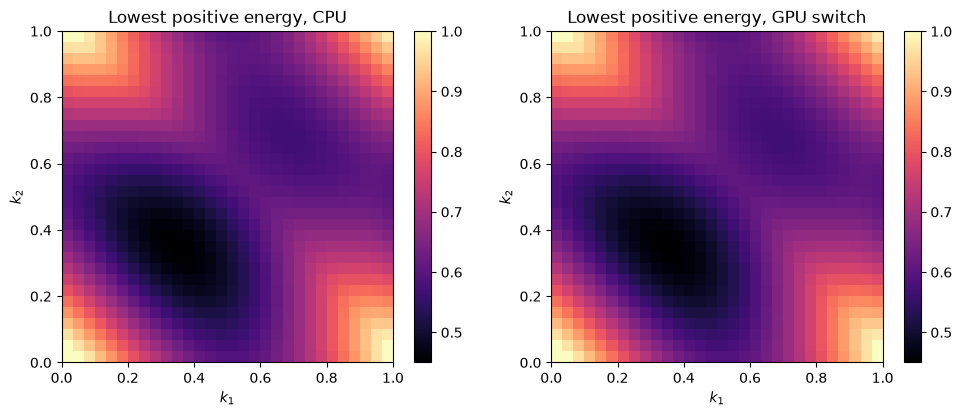

In [3]:
from pyqula import spectrum
g = geometry.honeycomb_lattice().get_supercell(4) # 32 sites, 64 orbitals with the spin
h = g.get_hamiltonian() # first-neighbor hopping
h.add_haldane(0.1) # open a topological gap
h.add_onsite(lambda r: 5.*(np.sum((r-g.r[0])**2)<1e-3)) # a strong defect on one site

nk = 30
gpu.set_gpu(False) ; es_cpu = spectrum.eigenvalues_kmesh(h,nk=nk) # (nk,nk,nbands)
gpu.set_gpu(True) ; es_gpu = spectrum.eigenvalues_kmesh(h,nk=nk)
gpu.set_gpu(False)
print("largest eigenvalue difference =",np.max(np.abs(es_gpu-es_cpu)))

def lowest_positive(es): # lowest positive energy at each k-point
    return np.min(np.where(es>0.,es,np.inf),axis=2)

fig,axs = plt.subplots(1,2,figsize=(10,4))
for ax,es,title in [(axs[0],es_cpu,"CPU"),(axs[1],es_gpu,"GPU switch")]:
    im = ax.imshow(lowest_positive(es).T,origin="lower",cmap="magma",extent=[0,1,0,1])
    ax.set_xlabel("$k_1$") ; ax.set_ylabel("$k_2$")
    ax.set_title("Lowest positive energy, "+title)
    plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()

### KPM density of states
Finally, the Chebyshev moments of a disordered square lattice with $10^4$ sites. The random
vectors of the stochastic trace are drawn in the same way on both paths, so with the same seed
the two densities of states coincide.

../../../src/pyqula/gpu.py:74: UserWarning: pyqula.gpu.set_gpu(True): jax sees no GPU on this machine, so the GPU code paths will run on jax's CPU backend instead
  warnings.warn("pyqula.gpu.set_gpu(True): jax sees no GPU on this "


largest relative difference = 4.217951594391874e-15


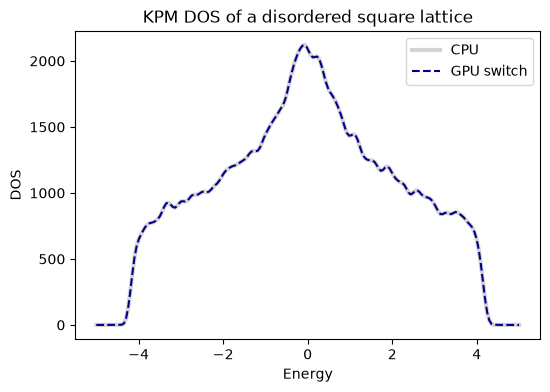

In [4]:
g = geometry.square_lattice().get_supercell(100) # 10000 sites
g.dimensionality = 0 # a finite system
h = g.get_hamiltonian(is_sparse=True,has_spin=False)
np.random.seed(2)
h.add_onsite(lambda r: 2.*(np.random.random()-0.5)) # Anderson disorder
energies = np.linspace(-5.,5.,200)

gpu.set_gpu(False) ; np.random.seed(1)
(x,y_cpu) = h.get_dos(mode="KPM",energies=energies,delta=5e-2,ntries=5)
gpu.set_gpu(True) ; np.random.seed(1)
(x,y_gpu) = h.get_dos(mode="KPM",energies=energies,delta=5e-2,ntries=5)
gpu.set_gpu(False)
print("largest relative difference =",np.max(np.abs(y_gpu-y_cpu))/np.max(y_cpu))

plt.figure(figsize=(6,4))
plt.plot(x,y_cpu,label="CPU",lw=3,c="lightgray")
plt.plot(x,y_gpu,label="GPU switch",ls="--",c="darkblue")
plt.xlabel("Energy") ; plt.ylabel("DOS") ; plt.legend()
plt.title("KPM DOS of a disordered square lattice")
plt.show()